# Antennal Tracking Analysis
**complete pieline**:
1. **Setup** — libraries, parameters,core functions
2. **Single video analysis** — exploring, plot, stats
3. **Loop on all the vido files** — features extraction
4. **Unsupervised clustering** — find nautral groups in the data
6. **Supervised classifier** — tries to train on mag vs nomag, applied to mag.nomag

## 1. Setup

In [27]:
# ============================================================
# LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal   import savgol_filter
from scipy.fft      import fft, fftfreq
from scipy.stats    import skew, kurtosis, pearsonr, gaussian_kde
from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.decomposition   import PCA
from sklearn.cluster         import KMeans
from sklearn.inspection      import permutation_importance
from sklearn.metrics         import classification_report
import pywt
import warnings
warnings.filterwarnings('ignore')

In [28]:
# ============================================================
# PARAMETERS — uploded from config.py (configuration file available in the directory)
# ============================================================
# All technical parameters (FPS, thresholds, smoothing) are stored in
#config.py in the videos folder. Edit them there.

import sys
sys.path.append("/Users/giorgia/Documents/AntennalMag_DEMO") #INSERT IN HERE PATH FOR VIDEOS/CONFIG FOLDER
from config import *

# Sliding window parameters (for time analysis)
WINDOW_SEC  = 10.0   # window time duration in seconds
STEP_SEC    =  2.0   # step between windows (overlap)

print(f"FPS                : {FPS}")
print(f"Likelihood thresh  : {LIKELIHOOD_THRESH}")
print(f"Velocity threshold : {VELOCITY_THRESHOLD} deg/s")
print(f"Savgol window      : {SAVGOL_WINDOW} frames")
print(f"Window size        : {WINDOW_SEC} s  |  Step: {STEP_SEC} s")

FPS                : 29.97
Likelihood thresh  : 0.8
Velocity threshold : 1000 deg/s
Savgol window      : 7 frames
Window size        : 10.0 s  |  Step: 2.0 s


## 2. Core Functions

Core functions are definde just once and used along all the analysisi pipeline. 

In [29]:
# ============================================================
# CORE FUNCTIONS
# ============================================================

# ---- uploading and filtering ----

def load_and_filter(csv_path):
    """Import CSV from DLC. Replaces low likelihood frames with NaN."""
    df   = pd.read_csv(csv_path, header=[0,1,2])
    df_f = df.copy()
    for bp in BODYPARTS:
        lk  = df_f.xs((bp, 'likelihood'), level=(1,2), axis=1).squeeze()
        bad = lk < LIKELIHOOD_THRESH
        df_f.loc[bad, (slice(None), bp, 'x')] = np.nan
        df_f.loc[bad, (slice(None), bp, 'y')] = np.nan
    return df, df_f

def get_coord(df_f, bp, axis):
    return df_f.xs((bp, axis), level=(1,2), axis=1).squeeze().to_numpy(dtype=float)

# ---- antennal geometry ----

def angle_between_vectors(v1x, v1y, v2x, v2y):
    """Angle (degrees) between two vectors, frame by frame."""
    dot   = v1x * v2x + v1y * v2y
    norm1 = np.sqrt(v1x**2 + v1y**2)
    norm2 = np.sqrt(v2x**2 + v2y**2)
    with np.errstate(invalid='ignore', divide='ignore'):
        cos_a = np.where((norm1 > 0) & (norm2 > 0),
                         dot / (norm1 * norm2), np.nan)
    return np.degrees(np.arccos(np.clip(cos_a, -1, 1)))

def compute_angles(df_f):
    """Calculate left and right angles about the head axis."""
    head_dx = get_coord(df_f,'F','x') - get_coord(df_f,'B','x')
    head_dy = get_coord(df_f,'F','y') - get_coord(df_f,'B','y')
    left_angle  = angle_between_vectors(
        head_dx, head_dy,
        get_coord(df_f,'AL','x') - get_coord(df_f,'ALH','x'),
        get_coord(df_f,'AL','y') - get_coord(df_f,'ALH','y'))
    right_angle = angle_between_vectors(
        head_dx, head_dy,
        get_coord(df_f,'AR','x') - get_coord(df_f,'ARH','x'),
        get_coord(df_f,'AR','y') - get_coord(df_f,'ARH','y'))
    return left_angle, right_angle

# ---- clening ----

def apply_bad_frames(angle_array, bad_frames_set):
    """Replaces frames marked as bad tracking with NaN."""
    arr = angle_array.copy()
    if bad_frames_set:
        idx = np.array(sorted(bad_frames_set), dtype=int)
        idx = idx[idx < len(arr)]
        arr[idx] = np.nan
    return arr

def load_bad_frames(video_stem):
    """Load the CSV of bad frames for a given video."""
    bf_file = BAD_FRAMES_DIR / (video_stem + "_bad_frames.csv")
    if bf_file.exists():
        frames = set(pd.read_csv(bf_file)['frame'].tolist())
        print(f"  Bad frames uploded: {len(frames)}")
        return frames
    return set()

def auto_remove_spikes(left_angle, right_angle):
    """Automatically removes N and N+1 frames where the speed exceeds the threshold."""
    for angle in [left_angle, right_angle]:
        vel = np.diff(angle) * FPS
        bad = set(
            f for i in np.where(np.abs(vel) > VELOCITY_THRESHOLD)[0]
            for f in [i, i+1] if i+1 < len(angle)
        )
        angle = apply_bad_frames(angle, bad)
    left_vel_raw  = np.diff(left_angle)  * FPS
    right_vel_raw = np.diff(right_angle) * FPS
    left_bad  = set(f for i in np.where(np.abs(left_vel_raw)  > VELOCITY_THRESHOLD)[0]
                    for f in [i, i+1] if f < len(left_angle))
    right_bad = set(f for i in np.where(np.abs(right_vel_raw) > VELOCITY_THRESHOLD)[0]
                    for f in [i, i+1] if f < len(right_angle))
    return apply_bad_frames(left_angle,  left_bad),            apply_bad_frames(right_angle, right_bad)

# ---- smoothing ----

def smooth_signal(angle_deg):
    """Short NaN interpolation + Savitzky-Golay filter."""
    interp = pd.Series(angle_deg).interpolate(
        method='linear', limit=NAN_INTERP_LIMIT).to_numpy()
    return savgol_filter(interp,
                         window_length=SAVGOL_WINDOW,
                         polyorder=SAVGOL_POLYORDER,
                         mode='nearest')

# ----features exctraction ----

def _stats(arr, prefix):
    """Calculates mean, std, median, skewness, kurtosis on a clean array."""
    clean = arr[~np.isnan(arr)]
    if len(clean) < 4:
        return {f'{prefix}_{s}': np.nan for s in
                ['mean','std','median','skewness','kurtosis']}
    return {
        f'{prefix}_mean'    : np.mean(clean),
        f'{prefix}_std'     : np.std(clean),
        f'{prefix}_median'  : np.median(clean),
        f'{prefix}_skewness': skew(clean),
        f'{prefix}_kurtosis': kurtosis(clean),
    }

def extract_features(left_smooth, right_smooth, video_stem, duration_s=None):
    """Extracts features for a video (or time window)."""
    left_vel = np.diff(left_smooth)  * FPS
    right_vel= np.diff(right_smooth) * FPS
    sym      = left_smooth - right_smooth
    mask     = ~np.isnan(left_smooth) & ~np.isnan(right_smooth)

    feat = {'video': video_stem}
    if duration_s is not None:
        feat['duration_s'] = duration_s

    feat.update(_stats(left_smooth,  'left_angle'))
    feat.update(_stats(right_smooth, 'right_angle'))
    feat.update(_stats(left_vel,     'left_vel'))
    feat.update(_stats(right_vel,    'right_vel'))
    feat.update(_stats(sym,          'symmetry'))

    feat['left_vel_abs_mean']  = np.nanmean(np.abs(left_vel))
    feat['right_vel_abs_mean'] = np.nanmean(np.abs(right_vel))
    feat['symmetry_abs_mean']  = np.nanmean(np.abs(sym))
    feat['left_vel_max_abs']   = np.nanmax(np.abs(left_vel))
    feat['right_vel_max_abs']  = np.nanmax(np.abs(right_vel))

    if mask.sum() > 4:
        r, p = pearsonr(left_smooth[mask], right_smooth[mask])
        feat['antenna_correlation_r'] = r
        feat['antenna_correlation_p'] = p
    else:
        feat['antenna_correlation_r'] = np.nan
        feat['antenna_correlation_p'] = np.nan

    return feat

def extract_features_window(left_smooth, right_smooth, start, video_stem):
    """Extracts features over a single time window."""
    wf = int(WINDOW_SEC * FPS)
    end = start + wf
    l = left_smooth[start:end]
    r = right_smooth[start:end]
    if np.sum(~np.isnan(l)) < wf * 0.5:
        return None
    feat = extract_features(l, r, video_stem)
    feat['window_start_s'] = start / FPS
    feat['window_end_s']   = end   / FPS
    return feat

print("Core functions are correctly defined.")

Core functions are correctly defined.


## 3. Single video analysis

Use this section to explore one video at a time before starting the loop.

In [4]:
# ============================================================
# VIDEO SELECTION
# ============================================================

csv_files = sorted(FOLDER.glob("*.csv"))

print("available CSV files:")
for i, f in enumerate(csv_files):
    print(f"  {i}  {f.name}")

available CSV files:
  0  antenna.up.mag.2DLC_resnet101_antenna_upMar27shuffle1_200000.csv
  1  antenna.up.mag.3DLC_resnet101_antenna_upMar27shuffle1_200000.csv
  2  antenna.up.mag.nomag.1DLC_resnet101_antenna_upMar27shuffle1_200000.csv
  3  antenna.up.mag.nomag.2DLC_resnet101_antenna_upMar27shuffle1_200000.csv
  4  antenna.up.mag.nomag.3DLC_resnet101_antenna_upMar27shuffle1_200000.csv
  5  antenna.up.nomag.1DLC_resnet101_antenna_upMar27shuffle1_200000.csv
  6  antenna.up.nomag.2DLC_resnet101_antenna_upMar27shuffle1_200000.csv
  7  antenna.up.nomag.3DLC_resnet101_antenna_upMar27shuffle1_200000.csv
  8  antenna.up.nomag.mag.1DLC_resnet101_antenna_upMar27shuffle1_200000.csv


In [30]:
# set the index of the file to analyze
FILE_INDEX = 5

# Automatic spike removal: True = removes everything above threshold without manual inspection
# False = only uses bad frames marked with spike_inspector

AUTO_REMOVE_SPIKES = False

csv_path   = csv_files[FILE_INDEX]
video_stem = csv_path.stem.split('DLC')[0].rstrip('_').rstrip('.')

print(f"Analyzing : {csv_path.name}")
print(f"Stem     : {video_stem}")

Analyzing : antenna.up.nomag.1DLC_resnet101_antenna_upMar27shuffle1_200000.csv
Stem     : antenna.up.nomag.1


In [31]:
# ============================================================
# QUALITY CHECK
# ============================================================

df, df_filtered = load_and_filter(csv_path)

print("QUALITY CHECK\n")
for bp in BODYPARTS:
    lk   = df.xs((bp, 'likelihood'), level=(1,2), axis=1).squeeze()
    good = (lk >= LIKELIHOOD_THRESH).mean() * 100
    print(f"  {bp}: {good:.1f}% frame affidabili")

QUALITY CHECK

  HL: 100.0% frame affidabili
  HR: 100.0% frame affidabili
  AL: 94.2% frame affidabili
  ALH: 99.2% frame affidabili
  AR: 99.7% frame affidabili
  ARH: 100.0% frame affidabili
  B: 100.0% frame affidabili
  F: 100.0% frame affidabili


In [32]:
# ============================================================
# ANGLE CALCULATION + CLEANING
# ============================================================
# Order of operations:
# 1. Calculate rough angles
# 2. Manually exclude bad frames (from spike_inspector)
# 3. Automatically remove residual spikes (if AUTO_REMOVE_SPIKES=True)
# 4. Smoothing

# 1. raw angles
left_angle_deg, right_angle_deg = compute_angles(df_filtered)

# 2. exclusion of manually marked bad frames
bad_frames      = load_bad_frames(video_stem)
left_angle_deg  = apply_bad_frames(left_angle_deg,  bad_frames)
right_angle_deg = apply_bad_frames(right_angle_deg, bad_frames)

# 3. automatic removal (optional)
if AUTO_REMOVE_SPIKES:
    left_angle_deg, right_angle_deg = auto_remove_spikes(
        left_angle_deg, right_angle_deg)
    print("Automatic spike removal applied.")

# 4. smoothing
left_angle_smooth  = smooth_signal(left_angle_deg)
right_angle_smooth = smooth_signal(right_angle_deg)

duration_s = len(left_angle_deg) / FPS
time       = np.arange(len(left_angle_deg)) / FPS

print(f"\nTotal frames  : {len(left_angle_deg)}")
print(f"Video duration  : {duration_s:.1f} s  ({duration_s/60:.1f} min)")
print(f"Frame valid L: {np.sum(~np.isnan(left_angle_deg))}")
print(f"Frame valid R: {np.sum(~np.isnan(right_angle_deg))}")

  Bad frames uploded: 16

Total frames  : 12206
Video duration  : 407.3 s  (6.8 min)
Frame valid L: 11401
Frame valid R: 12159


Residual Peak LEFT  (98)
Residual Peak RIGHT (6)

If there are many spikes, consider AUTO_REMOVE_SPIKES = True


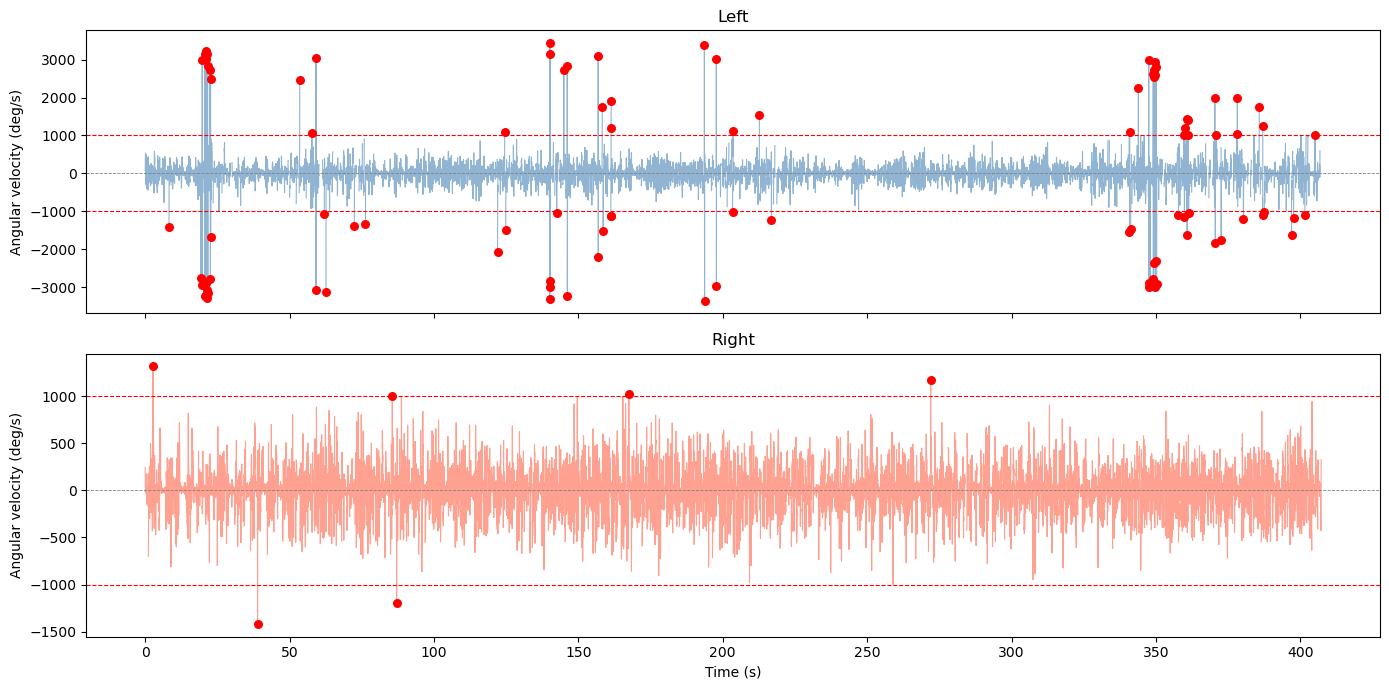

In [33]:
# ============================================================
# POST-CLEANING RESIDUAL PEAK CHECK
# ============================================================

left_vel_raw  = np.diff(left_angle_deg)  * FPS
right_vel_raw = np.diff(right_angle_deg) * FPS
left_spikes   = np.where(np.abs(left_vel_raw)  > VELOCITY_THRESHOLD)[0]
right_spikes  = np.where(np.abs(right_vel_raw) > VELOCITY_THRESHOLD)[0]

print(f"Residual Peak LEFT  ({len(left_spikes)})")
print(f"Residual Peak RIGHT ({len(right_spikes)})")

if len(left_spikes) > 0 or len(right_spikes) > 0:
    print("\nIf there are many spikes, consider AUTO_REMOVE_SPIKES = True")
    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    for ax, vel, spikes, label, color in zip(
        axes,
        [left_vel_raw, right_vel_raw],
        [left_spikes,  right_spikes],
        ['Left', 'Right'], ['steelblue','tomato']
    ):
        time_vel = np.arange(len(vel)) / FPS
        ax.plot(time_vel, vel, color=color, linewidth=0.8, alpha=0.6)
        ax.axhline( VELOCITY_THRESHOLD, linestyle='--', color='red', linewidth=0.8)
        ax.axhline(-VELOCITY_THRESHOLD, linestyle='--', color='red', linewidth=0.8)
        if len(spikes):
            ax.scatter(time_vel[spikes], vel[spikes], color='red', s=30, zorder=5)
        ax.axhline(0, linestyle='--', color='gray', linewidth=0.6)
        ax.set_ylabel("Angular velocity (deg/s)")
        ax.set_title(label)
    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()
else:
    print("No residual peaks — clean signal.")

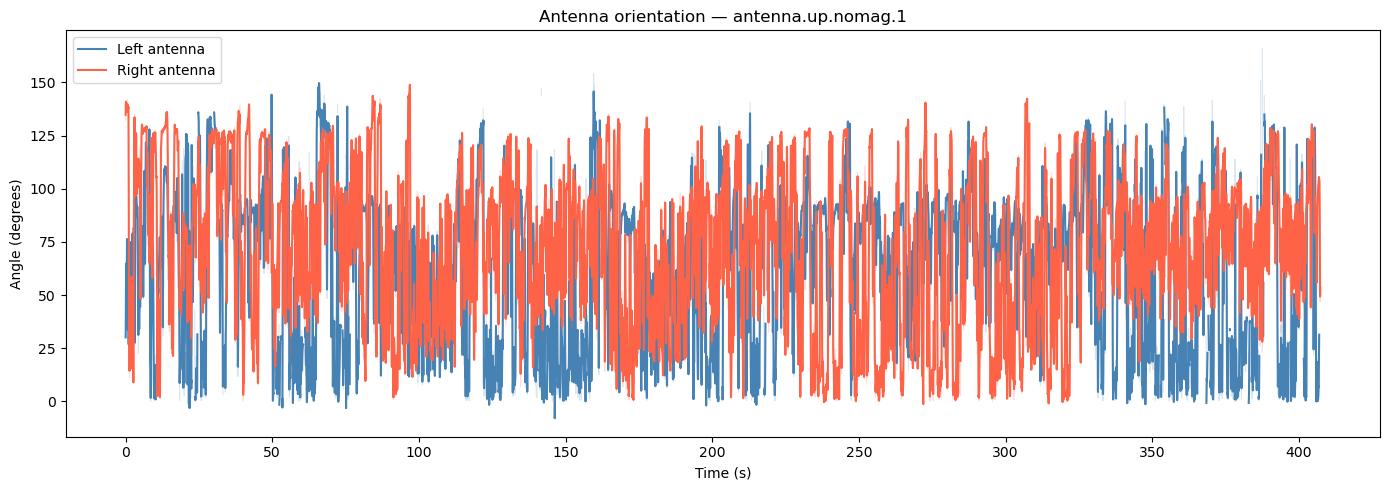

In [34]:
# ============================================================
# PLOT ANGLES IN TIME
# ============================================================
# Transparent line = raw signal, solid line = smoothed

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(time, left_angle_deg,    color='steelblue', alpha=0.2, linewidth=0.8)
ax.plot(time, left_angle_smooth, color='steelblue', linewidth=1.5, label='Left antenna')
ax.plot(time, right_angle_deg,    color='tomato', alpha=0.2, linewidth=0.8)
ax.plot(time, right_angle_smooth, color='tomato', linewidth=1.5, label='Right antenna')
ax.set_xlabel("Time (s)")
ax.set_ylabel("Angle (degrees)")
ax.set_title(f"Antenna orientation — {video_stem}")
ax.legend()
plt.tight_layout()
plt.show()

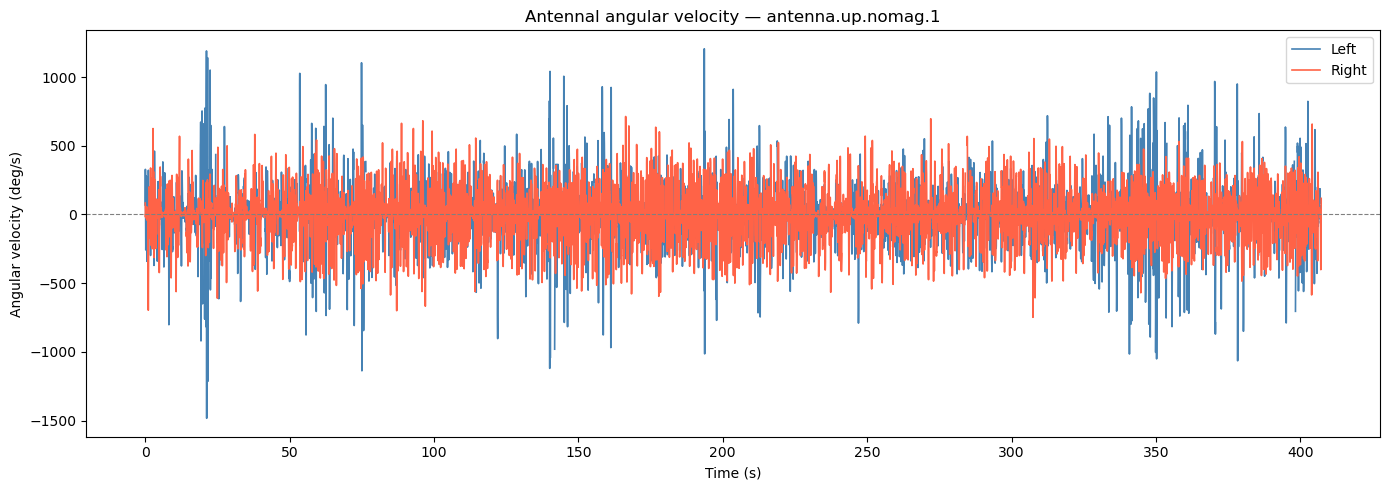

LEFT  — mean |vel|: 128.55 deg/s
RIGHT — mean |vel|: 135.02 deg/s


In [35]:
# ============================================================
# ANGULAR VELOCITY
# ============================================================

left_vel  = np.diff(left_angle_smooth)  * FPS
right_vel = np.diff(right_angle_smooth) * FPS
time_vel  = time[:-1]

# aliasing for FFT e Wavelet
left_angular_velocity  = left_vel
right_angular_velocity = right_vel

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(time_vel, left_vel,  color='steelblue', linewidth=1.2, label='Left')
ax.plot(time_vel, right_vel, color='tomato',    linewidth=1.2, label='Right')
ax.axhline(0, linestyle='--', color='gray', linewidth=0.8)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Angular velocity (deg/s)")
ax.set_title(f"Antennal angular velocity — {video_stem}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"LEFT  — mean |vel|: {np.nanmean(np.abs(left_vel)):.2f} deg/s")
print(f"RIGHT — mean |vel|: {np.nanmean(np.abs(right_vel)):.2f} deg/s")

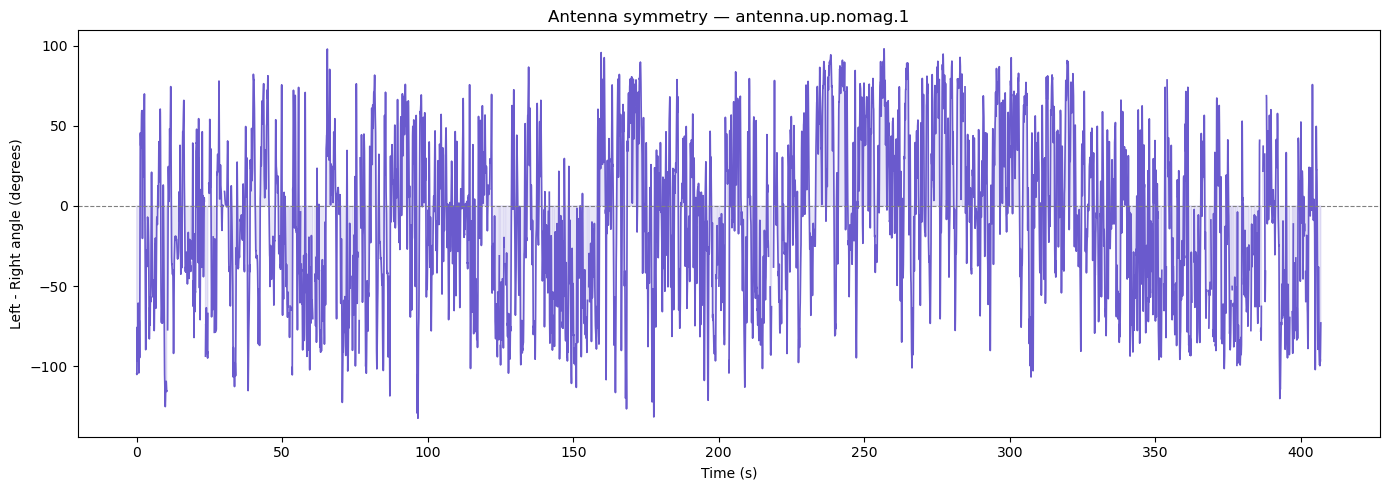

In [36]:
# ============================================================
# SYMMETRY
# ============================================================
# Value 0 = symmetrical antennas
# Positive = left antenna more open
# Negative = right antenna more open

symmetry = left_angle_smooth - right_angle_smooth

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(time, symmetry, color='slateblue', linewidth=1.2)
ax.axhline(0, linestyle='--', color='gray', linewidth=0.8)
ax.fill_between(time, symmetry, 0, alpha=0.15, color='slateblue')
ax.set_xlabel("Time (s)")
ax.set_ylabel("Left - Right angle (degrees)")
ax.set_title(f"Antenna symmetry — {video_stem}")
plt.tight_layout()
plt.show()

Correlazione Pearson (left vs right): r = 0.078,  p = 0.0000
→ Partially independent movements


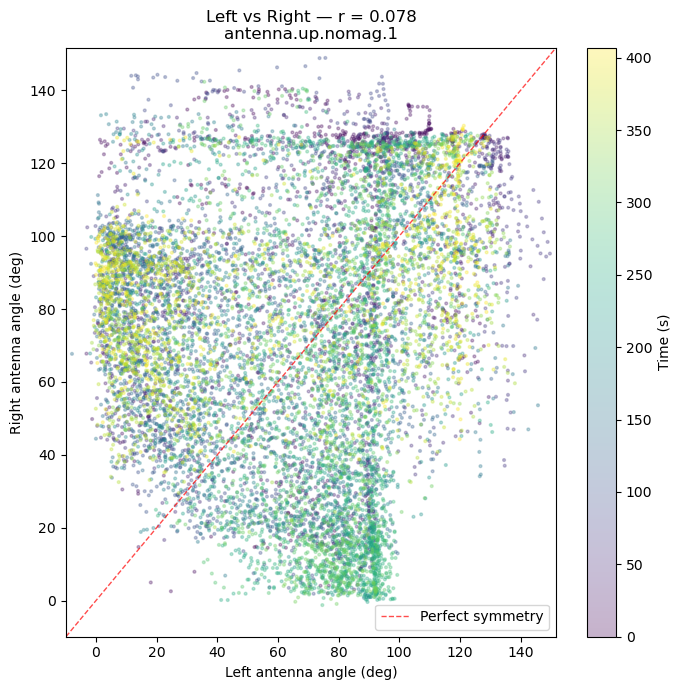

In [37]:
# ============================================================
# CORRELATION BETWEEN THE TWO ANTENNAS
# ============================================================
# r near +1 = parallel antennas (synchronized movements)
# r near -1 = divergent antennas (opposite movements)
# r near 0 = independent movements

mask = ~np.isnan(left_angle_smooth) & ~np.isnan(right_angle_smooth)
r, p = pearsonr(left_angle_smooth[mask], right_angle_smooth[mask])

print(f"Correlazione Pearson (left vs right): r = {r:.3f},  p = {p:.4f}")
if   r >  0.7: print("→ Mostly parallel antennas")
elif r < -0.7: print("→ Mainly divergent antennas")
else:          print("→ Partially independent movements")

# Scatter left vs right — the point cloud shows
# the typical angle and whether the antennas move together
# the color scale represents the different timepoints of the video
fig, ax = plt.subplots(figsize=(7, 7))
sc = ax.scatter(
    left_angle_smooth[mask], right_angle_smooth[mask],
    c=np.where(mask)[0] / FPS, cmap='viridis', alpha=0.3, s=4)
plt.colorbar(sc, ax=ax, label='Time (s)')
lims = [min(left_angle_smooth[mask].min(), right_angle_smooth[mask].min()) - 2,
        max(left_angle_smooth[mask].max(), right_angle_smooth[mask].max()) + 2]
ax.plot(lims, lims, 'r--', linewidth=1, alpha=0.7, label='Perfect symmetry')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Left antenna angle (deg)")
ax.set_ylabel("Right antenna angle (deg)")
ax.set_title(f"Left vs Right — r = {r:.3f}\n{video_stem}")
ax.legend()
plt.tight_layout()
plt.show()

In [38]:
# ============================================================
# COMPLETE STATISTICS
# ============================================================

def print_stats(label, data):
    clean = data[~np.isnan(data)]
    print(f"  Mean     : {np.mean(clean):.2f}")
    print(f"  Std      : {np.std(clean):.2f}")
    print(f"  Median   : {np.median(clean):.2f}")
    print(f"  Skewness : {skew(clean):.3f}")
    print(f"  Kurtosis : {kurtosis(clean):.3f}")

for label, data in [
    ("ANGLE — LEFT",          left_angle_smooth),
    ("ANGLE— RIGHT",         right_angle_smooth),
    ("ANGULAR VELOCITY — LEFT",  left_vel),
    ("ANGULAR VELOCITY — RIGHT", right_vel),
    ("SYMMETRY",              symmetry),
]:
    print("=" * 40)
    print(label)
    print_stats(label, data)
print("=" * 40)

ANGLE — LEFT
  Mean     : 64.43
  Std      : 36.24
  Median   : 71.02
  Skewness : -0.125
  Kurtosis : -1.067
ANGLE— RIGHT
  Mean     : 72.65
  Std      : 35.42
  Median   : 75.75
  Skewness : -0.188
  Kurtosis : -0.903
ANGULAR VELOCITY — LEFT
  Mean     : 1.12
  Std      : 195.85
  Median   : 5.81
  Skewness : -0.178
  Kurtosis : 4.914
ANGULAR VELOCITY — RIGHT
  Mean     : -0.12
  Std      : 182.24
  Median   : 6.80
  Skewness : -0.106
  Kurtosis : 0.595
SYMMETRY
  Mean     : -7.97
  Std      : 49.00
  Median   : -8.33
  Skewness : -0.004
  Kurtosis : -0.847


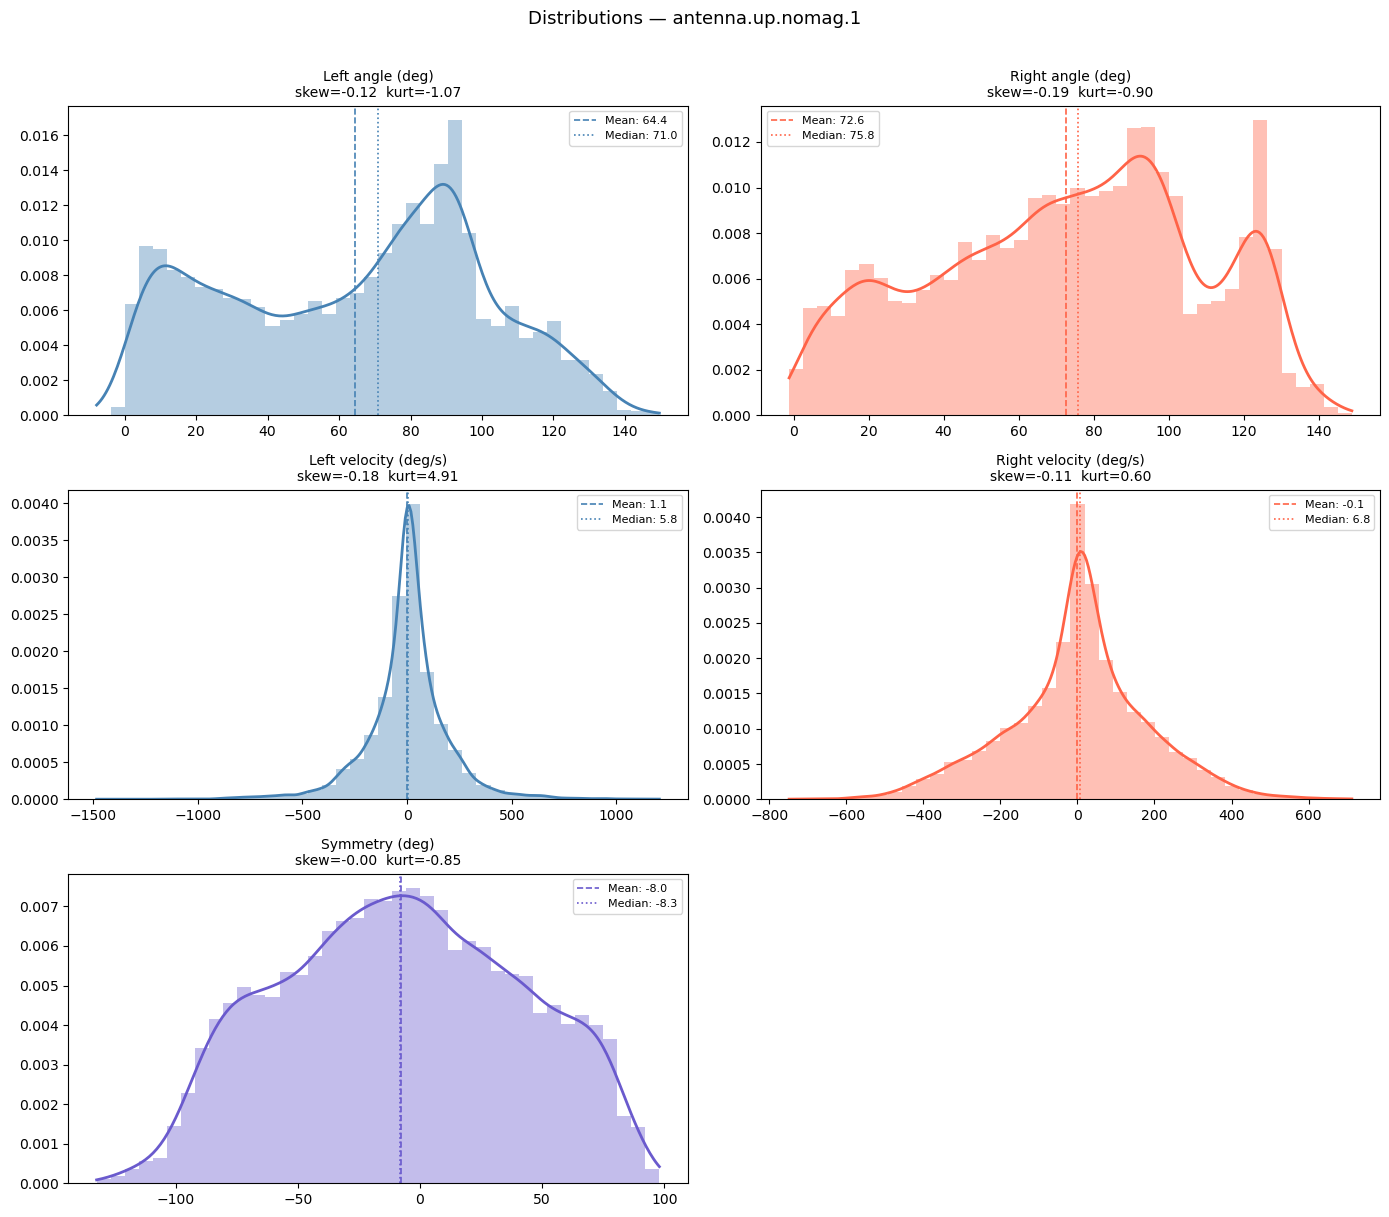

In [39]:
# ============================================================
# PLOT DISTRIBUTIONS
# ============================================================

def plot_distribution(ax, data, label, color):
    clean = data[~np.isnan(data)]
    ax.hist(clean, bins=40, color=color, alpha=0.4, density=True)
    kde = gaussian_kde(clean)
    x   = np.linspace(clean.min(), clean.max(), 300)
    ax.plot(x, kde(x), color=color, linewidth=2)
    ax.axvline(np.mean(clean),   color=color, linestyle='--', linewidth=1.2,
               label=f'Mean: {np.mean(clean):.1f}')
    ax.axvline(np.median(clean), color=color, linestyle=':', linewidth=1.2,
               label=f'Median: {np.median(clean):.1f}')
    sk = skew(clean); ku = kurtosis(clean)
    ax.set_title(f"{label}\nskew={sk:.2f}  kurt={ku:.2f}", fontsize=10)
    ax.legend(fontsize=8)

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
plot_distribution(axes[0,0], left_angle_smooth,  "Left angle (deg)",       "steelblue")
plot_distribution(axes[0,1], right_angle_smooth, "Right angle (deg)",      "tomato")
plot_distribution(axes[1,0], left_vel,           "Left velocity (deg/s)",  "steelblue")
plot_distribution(axes[1,1], right_vel,          "Right velocity (deg/s)", "tomato")
plot_distribution(axes[2,0], symmetry,           "Symmetry (deg)",         "slateblue")
axes[2,1].set_visible(False)
plt.suptitle(f"Distributions — {video_stem}", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

Dominant frequency — LEFT  : 2.14 Hz
Dominant frequency — RIGHT : 2.00 Hz


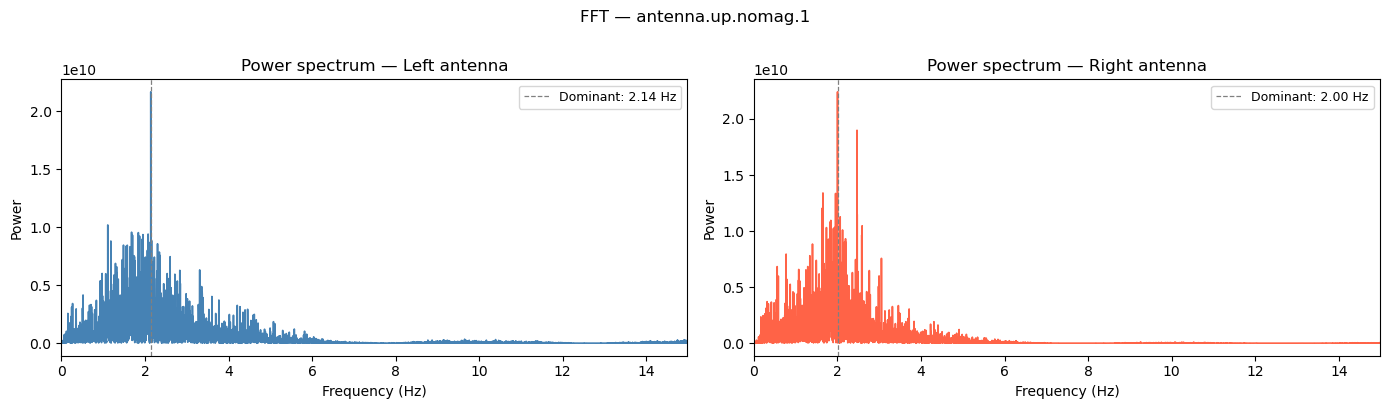

In [40]:
# ============================================================
#  FOURIER TRANSFORM - FFT — power spectrum of angular velocity
# ============================================================
# Shows which oscillation frequencies are present in the video.
# Useful if the behavior is stable throughout the entire duration.

def compute_fft(signal):
    sig = signal.copy()
    sig[np.isnan(sig)] = np.nanmean(sig)
    n     = len(sig)
    freqs = fftfreq(n, d=1/FPS)
    power = np.abs(fft(sig))**2
    pos   = freqs > 0
    return freqs[pos], power[pos]

freqs_l, power_l = compute_fft(left_angular_velocity)
freqs_r, power_r = compute_fft(right_angular_velocity)

dom_l = freqs_l[np.argmax(power_l)]
dom_r = freqs_r[np.argmax(power_r)]

print(f"Dominant frequency — LEFT  : {dom_l:.2f} Hz")
print(f"Dominant frequency — RIGHT : {dom_r:.2f} Hz")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, freqs, power, dom, label, color in zip(
    axes, [freqs_l, freqs_r], [power_l, power_r],
    [dom_l, dom_r], ['Left','Right'], ['steelblue','tomato']
):
    ax.plot(freqs, power, color=color, linewidth=1.2)
    ax.axvline(dom, linestyle='--', color='gray', linewidth=0.9,
               label=f'Dominant: {dom:.2f} Hz')
    ax.set_xlabel("Frequency (Hz)"); ax.set_ylabel("Power")
    ax.set_title(f"Power spectrum — {label} antenna")
    ax.set_xlim(0, FPS/2); ax.legend(fontsize=9)
plt.suptitle(f"FFT — {video_stem}", y=1.01)
plt.tight_layout(); plt.show()

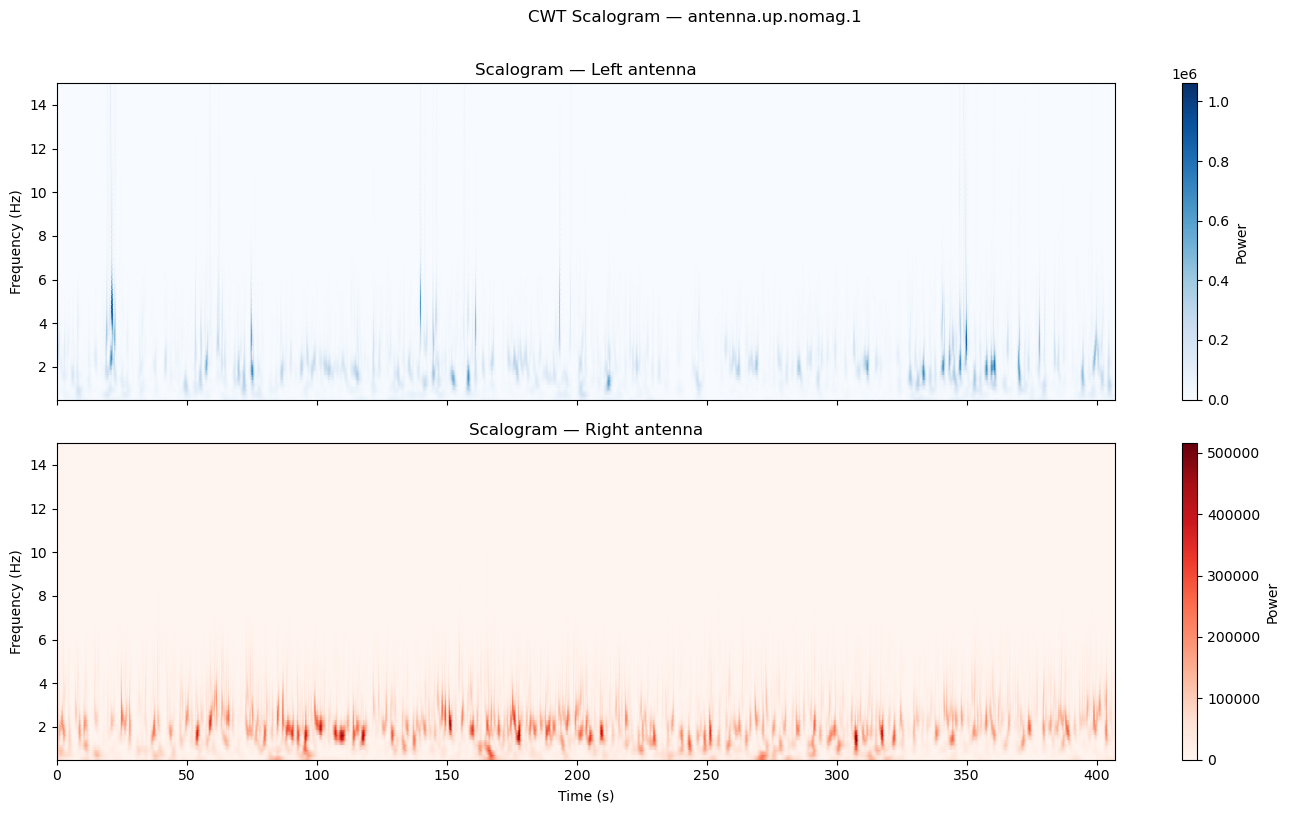

In [41]:
# ============================================================
# WAVELET (CWT) — frequencies over time
# ============================================================
# Shows how frequencies change over the course of the video.
# Useful if behavior varies during recording.

def compute_cwt(signal, wavelet='cmor1.5-1.0'):
    sig = signal.copy()
    sig[np.isnan(sig)] = np.nanmean(sig)
    freqs_target = np.linspace(0.5, FPS/2, 64)
    scales       = pywt.frequency2scale(wavelet, freqs_target / FPS)
    coeffs, freqs_cwt = pywt.cwt(sig, scales, wavelet, sampling_period=1/FPS)
    return freqs_cwt, np.abs(coeffs)**2

freqs_cwt_l, power_cwt_l = compute_cwt(left_angular_velocity)
freqs_cwt_r, power_cwt_r = compute_cwt(right_angular_velocity)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ax, power, freqs, label, cmap in zip(
    axes,
    [power_cwt_l, power_cwt_r],
    [freqs_cwt_l, freqs_cwt_r],
    ['Left antenna', 'Right antenna'],
    ['Blues', 'Reds']
):
    im = ax.pcolormesh(time_vel, freqs, power, shading='gouraud', cmap=cmap)
    ax.set_ylabel("Frequency (Hz)")
    ax.set_title(f"Scalogram — {label}")
    plt.colorbar(im, ax=ax, label="Power")
axes[-1].set_xlabel("Time (s)")
plt.suptitle(f"CWT Scalogram — {video_stem}", y=1.01)
plt.tight_layout(); plt.show()

## 4. Loop on all videos → descriptive statistics and exctracting features for classifiers

It processes all CSVs, applies the same pipeline as for individual videos,
and produces two outputs:
- `features_all_videos.csv` — one row per video (global features)
- `features_windows.csv` — one row per time window (for temporal analysis and clustering)

In [51]:
# ============================================================
# LOOP ON ALL VIDEOS
# ============================================================

# CONFIGURATION FLAGS: Freely control the cleaning strategy
USE_MANUAL_SPIKES  = False # If True use hand-marked bad frames (if available)
AUTO_REMOVE_SPIKES = True   # If True applies automatic threshold-based filtering

all_features = []
all_windows  = []

# exclude output files from analysis
EXCLUDE = {
    'features_all_videos.csv', 
    'features_windows.csv', 
    'descriptive_statistics_condition.csv' 
}
csv_files_all = sorted(
    f for f in FOLDER.glob("*.csv")
    if f.name not in EXCLUDE
)
print(f"Found {len(csv_files_all)} CSV file to analyze")
print(f"Activated Strategy: Manual={USE_MANUAL_SPIKES} | Automatic={AUTO_REMOVE_SPIKES}\n")

for csv_path_i in csv_files_all:

    stem_i = csv_path_i.stem.split('DLC')[0].rstrip('_').rstrip('.')
    print(f"Processing: {stem_i}")

    try:
        # upload and filtering
        _, df_f_i = load_and_filter(csv_path_i)

        # raw angles
        left_i, right_i = compute_angles(df_f_i)

        # IDENTIFICATION AND MANUAL APPLICATION (DEPENDING ON THE FLAG)
        if USE_MANUAL_SPIKES:
            bad_i   = load_bad_frames(stem_i)
            left_i  = apply_bad_frames(left_i,  bad_i)
            right_i = apply_bad_frames(right_i, bad_i)
            print("  -> Manual bad frames applied")

        #  AUTOMATIC SPIKE REMOVAL (FLAG-TRIGGED)
        if AUTO_REMOVE_SPIKES:
            left_i, right_i = auto_remove_spikes(left_i, right_i)
            print("  -> Automatic spike removal applied")

        # 5. smoothing
        left_s  = smooth_signal(left_i)
        right_s = smooth_signal(right_i)
        dur_s   = len(left_s) / FPS

        # 6. global features (one per video)
        feat = extract_features(left_s, right_s, stem_i, duration_s=dur_s)
        all_features.append(feat)

        # 7. features for time windows
        wf = int(WINDOW_SEC * FPS)
        sf = int(STEP_SEC   * FPS)
        for start in range(0, len(left_s) - wf, sf):
            w = extract_features_window(left_s, right_s, start, stem_i)
            if w is not None:
                all_windows.append(w)

        print(f"  OK — {dur_s:.0f} s  |  {len(left_s)} frame\n")

    except Exception as e:
        print(f"  ERROR: {e}\n")
        continue

# save
features_df = pd.DataFrame(all_features)
windows_df  = pd.DataFrame(all_windows)

features_df.to_csv(FEATURES_OUTPUT, index=False)
windows_df.to_csv( FOLDER / "features_windows.csv", index=False)

print(f"Global Features  : {features_df.shape}  →  {FEATURES_OUTPUT.name}")
print(f"Features windows : {windows_df.shape}  →  features_windows.csv")
features_df

Found 9 CSV file to analyze
Activated Strategy: Manual=False | Automatic=True

Processing: antenna.up.mag.2
  -> Automatic spike removal applied
  OK — 350 s  |  10477 frame

Processing: antenna.up.mag.3
  -> Automatic spike removal applied
  OK — 302 s  |  9064 frame

Processing: antenna.up.mag.nomag.1
  -> Automatic spike removal applied
  OK — 600 s  |  17984 frame

Processing: antenna.up.mag.nomag.2
  -> Automatic spike removal applied
  OK — 480 s  |  14391 frame

Processing: antenna.up.mag.nomag.3
  -> Automatic spike removal applied
  OK — 482 s  |  14433 frame

Processing: antenna.up.nomag.1
  -> Automatic spike removal applied
  OK — 407 s  |  12206 frame

Processing: antenna.up.nomag.2
  -> Automatic spike removal applied
  OK — 301 s  |  9009 frame

Processing: antenna.up.nomag.3
  -> Automatic spike removal applied
  OK — 308 s  |  9227 frame

Processing: antenna.up.nomag.mag.1
  -> Automatic spike removal applied
  OK — 480 s  |  14392 frame

Global Features  : (9, 34)  → 

,video,duration_s,left_angle_mean,left_angle_std,left_angle_median,left_angle_skewness,left_angle_kurtosis,right_angle_mean,right_angle_std,right_angle_median,...,symmetry_median,symmetry_skewness,symmetry_kurtosis,left_vel_abs_mean,right_vel_abs_mean,symmetry_abs_mean,left_vel_max_abs,right_vel_max_abs,antenna_correlation_r,antenna_correlation_p
0,antenna.up.mag.2,349.582916,67.148045,31.494919,71.472454,-0.172815,-0.799122,67.994461,35.718399,71.121680,...,-0.871321,-0.045809,-0.740237,153.973963,172.944747,38.200609,1118.029512,852.727358,0.071575,6.287319e-13
1,antenna.up.mag.3,302.435769,65.189589,37.373493,71.478949,-0.062890,-1.177525,74.007564,32.265054,77.443041,...,-12.822762,0.173852,-0.839040,149.204362,158.394464,39.448087,1110.952230,735.152250,0.154036,1.016456e-45
2,antenna.up.mag.nomag.1,600.066733,69.926562,37.848396,72.300932,-0.060036,-1.208561,55.045905,39.361758,52.978527,...,15.221975,-0.101383,-0.494001,194.494837,166.839691,39.686565,1382.842424,960.865905,0.286782,3.760066e-315
3,antenna.up.mag.nomag.2,480.180180,19.930972,18.024452,17.167721,2.939695,11.169170,18.239082,16.061675,16.539229,...,0.724879,1.197520,8.932359,59.119516,49.019820,9.952905,1005.913880,563.177629,0.594788,0.000000e+00
4,antenna.up.mag.nomag.3,481.581582,15.647822,15.453665,12.678027,3.349905,15.820384,14.889292,12.027611,13.615822,...,-0.298580,1.846539,13.124170,49.007815,38.954442,8.629646,710.032301,743.153193,0.530263,0.000000e+00
5,antenna.up.nomag.1,407.273941,64.169766,36.315403,70.771022,-0.118351,-1.083518,72.640754,35.400264,75.733009,...,-8.843730,0.007761,-0.858065,122.315957,135.053778,41.525058,1138.091424,748.755100,0.078507,2.511928e-17
6,antenna.up.nomag.2,300.600601,67.259055,34.719613,71.638069,-0.115341,-1.078024,73.405305,33.222387,74.611075,...,-8.046856,0.116691,-0.576348,147.776485,156.350265,36.260715,1149.362535,812.093818,0.182917,1.269854e-65
7,antenna.up.nomag.3,307.874541,65.630229,35.124701,74.076391,-0.240426,-1.104868,71.525982,34.900170,75.205432,...,-8.311417,0.100162,-0.823591,145.490859,150.754803,39.464017,1083.199625,827.379404,0.123017,6.881834e-31
8,antenna.up.nomag.mag.1,480.213547,47.715335,38.404380,33.108272,0.631007,-0.926580,37.544542,33.776166,22.444510,...,4.145545,0.255843,0.548043,144.037156,114.628424,26.743955,1101.451004,874.927110,0.523382,0.000000e+00


## 5. Label assignment
Automatically assigns the experimental condition to each video.
Recognized labels are: `mag`, `nomag`, `mag.nomag`.

In [48]:
# ============================================================
# LABEL ASSIGNMENT
# ============================================================
# The code attempts to assign the label automatically from the
# video file name (mag / nomag / mag.nomag).
# If the name doesn't contain these strings, the label remains NaN
# and you must manually complete it in the label_map dictionary.

def infer_label(stem):
    s = stem.lower()
    if 'mag.nomag' in s or 'nomag.mag' in s:
        return 'mag.nomag'
    elif 'nomag' in s:
        return 'nomag'
    elif 'mag' in s:
        return 'mag'
    return None

features_df = pd.read_csv(FEATURES_OUTPUT)
features_df['label'] = features_df['video'].apply(infer_label)

# If some videos don't have automatic labels, add them here:
label_map = {
    # example: 'video_name' : 'label',
}
for stem, label in label_map.items():
    features_df.loc[features_df['video'] == stem, 'label'] = label

# report
counts  = features_df['label'].value_counts(dropna=False)
missing = features_df[features_df['label'].isna()]['video'].tolist()
print("Distribuzione label:")
print(counts.to_string())
if missing:
    print(f"\nATTENZIONE — video senza label: {missing}")
    print("Aggiungili nel dizionario label_map sopra.")
else:
    print("\nAll the labels are assigned.")

features_df.to_csv(FEATURES_OUTPUT, index=False)

# add labels to windows too
windows_df = pd.read_csv(FOLDER / "features_windows.csv")
windows_df['label'] = windows_df['video'].apply(infer_label)
for stem, label in label_map.items():
    windows_df.loc[windows_df['video'] == stem, 'label'] = label
windows_df.to_csv(FOLDER / "features_windows.csv", index=False)

features_df[['video','label','duration_s']].head(20)

Distribuzione label:
label
mag.nomag    4
nomag        3
mag          2

All the labels are assigned.


,video,label,duration_s
0,antenna.up.mag.2,mag,349.582916
1,antenna.up.mag.3,mag,302.435769
2,antenna.up.mag.nomag.1,mag.nomag,600.066733
3,antenna.up.mag.nomag.2,mag.nomag,480.180180
4,antenna.up.mag.nomag.3,mag.nomag,481.581582
5,antenna.up.nomag.1,nomag,407.273941
6,antenna.up.nomag.2,nomag,300.600601
7,antenna.up.nomag.3,nomag,307.874541
8,antenna.up.nomag.mag.1,mag.nomag,480.213547


DESCRIPTIVE STATISTICS BY CONDITION

Table successfully exported to file: /Users/giorgia/Documents/AntennalMag_DEMO/descriptive_statistics_condition.csv



,label,left_angle_mean_median,left_angle_mean_mean,left_angle_mean_std,left_angle_mean_count,right_angle_mean_median,right_angle_mean_mean,right_angle_mean_std,right_angle_mean_count,left_angle_std_median,...,symmetry_std_std,symmetry_std_count,symmetry_skewness_median,symmetry_skewness_mean,symmetry_skewness_std,symmetry_skewness_count,antenna_correlation_r_median,antenna_correlation_r_mean,antenna_correlation_r_std,antenna_correlation_r_count
0,mag,66.012883,66.012883,1.537180,2,70.898403,70.898403,4.442148,2,34.414795,...,0.289752,2,0.069783,0.069783,0.159626,2,0.114982,0.114982,0.059869,2
1,mag.nomag,33.766705,38.276949,25.453150,4,27.828619,31.398109,18.672976,4,27.864866,...,15.985908,4,0.709005,0.790791,0.882169,4,0.526823,0.481418,0.132677,4
2,nomag,65.630229,65.702144,1.522228,3,72.649676,72.526988,0.945650,3,35.124701,...,2.680284,3,0.100162,0.074294,0.059693,3,0.123017,0.128027,0.052564,3


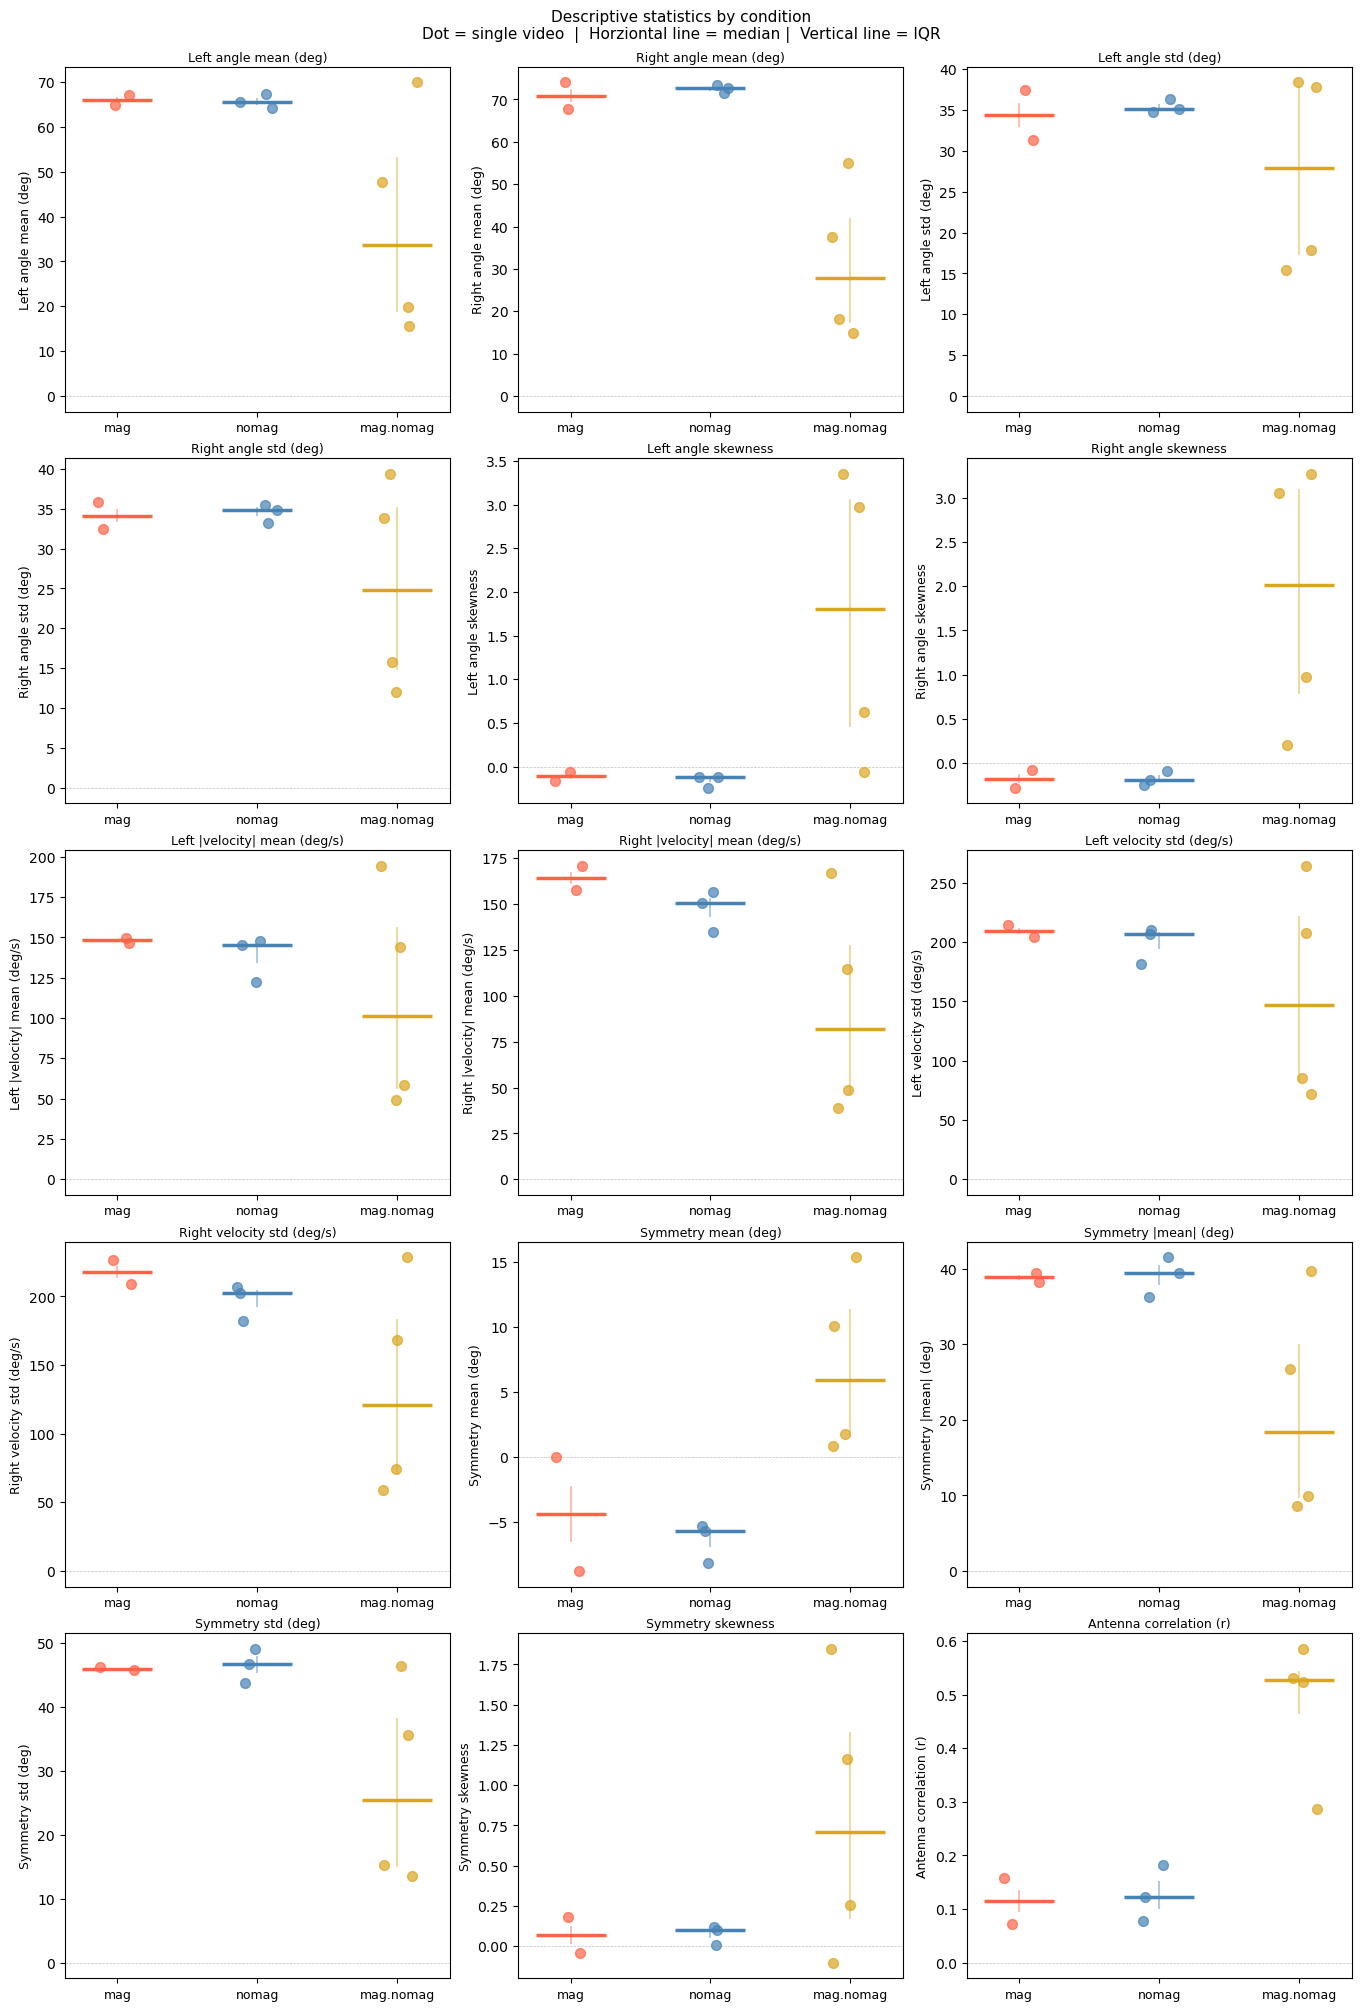

Figure saved in: descriptive_by_condition.pdf


In [49]:
# ============================================================
# DESCRIPTIVE STATISTICS AND PLOT BY CONDITION
# ============================================================

features_df = pd.read_csv(FEATURES_OUTPUT)

# measures to display — edit in here if you want to add/remove some
MEASURES = {
    'left_angle_mean'        : 'Left angle mean (deg)',
    'right_angle_mean'       : 'Right angle mean (deg)',
    'left_angle_std'         : 'Left angle std (deg)',
    'right_angle_std'        : 'Right angle std (deg)',
    'left_angle_skewness'    : 'Left angle skewness',
    'right_angle_skewness'   : 'Right angle skewness',
    'left_vel_abs_mean'      : 'Left |velocity| mean (deg/s)',
    'right_vel_abs_mean'     : 'Right |velocity| mean (deg/s)',
    'left_vel_std'           : 'Left velocity std (deg/s)',
    'right_vel_std'          : 'Right velocity std (deg/s)',
    'symmetry_mean'          : 'Symmetry mean (deg)',
    'symmetry_abs_mean'      : 'Symmetry |mean| (deg)',
    'symmetry_std'           : 'Symmetry std (deg)',
    'symmetry_skewness'      : 'Symmetry skewness',
    'antenna_correlation_r'  : 'Antenna correlation (r)',
}

CONDITIONS  = ['mag', 'nomag', 'mag.nomag']
COND_COLORS = {'mag': 'tomato', 'nomag': 'steelblue', 'mag.nomag': 'goldenrod'}

# ---- descriptive table ----
print("DESCRIPTIVE STATISTICS BY CONDITION\n")

# Statistics calculation 
desc = features_df.groupby('label')[list(MEASURES.keys())].agg(['median', 'mean', 'std', 'count'])

# Flattening MultiIndex columns (combines metrics + statistics)
desc.columns = [f"{col[0]}_{col[1]}" for col in desc.columns]

# Transforming the 'label' index into a standard table column
desc = desc.reset_index()

# Save in CSV format (semicolon separator optimized for Excel)

csv_output_name = "descriptive_statistics_condition.csv"
csv_output_path = FOLDER / csv_output_name  

desc.to_csv(csv_output_path, index=False, sep=';')
print(f"Table successfully exported to file: {csv_output_path}\n")

# Rendering the table in a graphic format readable within the Notebook
display(desc)
print()

# ---- strip plot for each measure ----
n_measures = len(MEASURES)
ncols = 3
nrows = int(np.ceil(n_measures / ncols))

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 4.5, nrows * 4),
                         constrained_layout=True)
axes = axes.flatten()

rng = np.random.default_rng(42)  # reproducible jitter

for ax, (col, ylabel) in zip(axes, MEASURES.items()):
    for ci, cond in enumerate(CONDITIONS):
        sub  = features_df[features_df['label'] == cond][col].dropna()
        if len(sub) == 0:
            continue

        color = COND_COLORS[cond]
        x_pos = ci

        # horizontal jitter to avoid overlapping points
        jitter = rng.uniform(-0.15, 0.15, size=len(sub))

        # every dot is a Video 
        ax.scatter(x_pos + jitter, sub,
                   color=color, s=50, alpha=0.7, zorder=3)

        # median of the group
        med = sub.median()
        ax.hlines(med, x_pos - 0.25, x_pos + 0.25,
                  colors=color, linewidths=2.5, zorder=4)

        # IQR (25° - 75° percentile) as a vertical thin line 
        q25, q75 = sub.quantile(0.25), sub.quantile(0.75)
        ax.vlines(x_pos, q25, q75,
                  colors=color, linewidths=1.2, alpha=0.5, zorder=2)

    ax.set_xticks(range(len(CONDITIONS)))
    ax.set_xticklabels(CONDITIONS, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(ylabel, fontsize=9, pad=4)
    ax.axhline(0, linestyle='--', color='gray', linewidth=0.5, alpha=0.5)

# removes empty panels 
for ax in axes[n_measures:]:
    ax.set_visible(False)

plt.suptitle("Descriptive statistics by condition\n"
             "Dot = single video  |  Horziontal line = median |  "
             "Vertical line = IQR",
             fontsize=11)
plt.savefig(FOLDER / "descriptive_by_condition.pdf",
            bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved in: descriptive_by_condition.pdf")

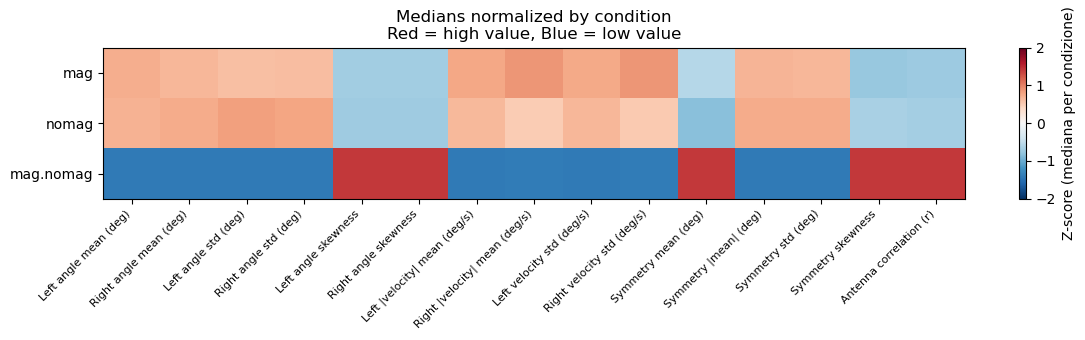

Heatmap saved in: heatmap_by_condition.pdf


In [50]:
# ============================================================
# HEATMAP — medians by condition (overall view)
# ============================================================

# calculates medians and normalizes by row (z-scores across conditions)
# so measurements on different scales are visually comparable

med_table = features_df.groupby('label')[list(MEASURES.keys())].median()
med_table = med_table.reindex(CONDITIONS).dropna(how='all')

# z-score per column (normalize across conditions)
from scipy.stats import zscore
med_norm = med_table.apply(zscore, nan_policy='omit')
med_norm.columns = list(MEASURES.values())

fig, ax = plt.subplots(figsize=(len(MEASURES)*0.8, 3.5))
im = ax.imshow(med_norm.values, aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)
plt.colorbar(im, ax=ax, label='Z-score (mediana per condizione)')

ax.set_xticks(range(len(MEASURES)))
ax.set_xticklabels(list(MEASURES.values()),
                   rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(med_norm)))
ax.set_yticklabels(med_norm.index, fontsize=10)
ax.set_title("Medians normalized by condition\n"
             "Red = high value, Blue = low value")
plt.tight_layout()
plt.savefig(FOLDER / "heatmap_by_condition.pdf", bbox_inches='tight', dpi=150)
plt.show()
print("Heatmap saved in: heatmap_by_condition.pdf")

## 6. Unsupervised Clustering 
Finds natural groups in the data **without using labels**.
Useful for understanding whether mag and nomag separate spontaneously,
and for exploring mag.nomag videos.

Variance explained by PC1+PC2: 86.4%


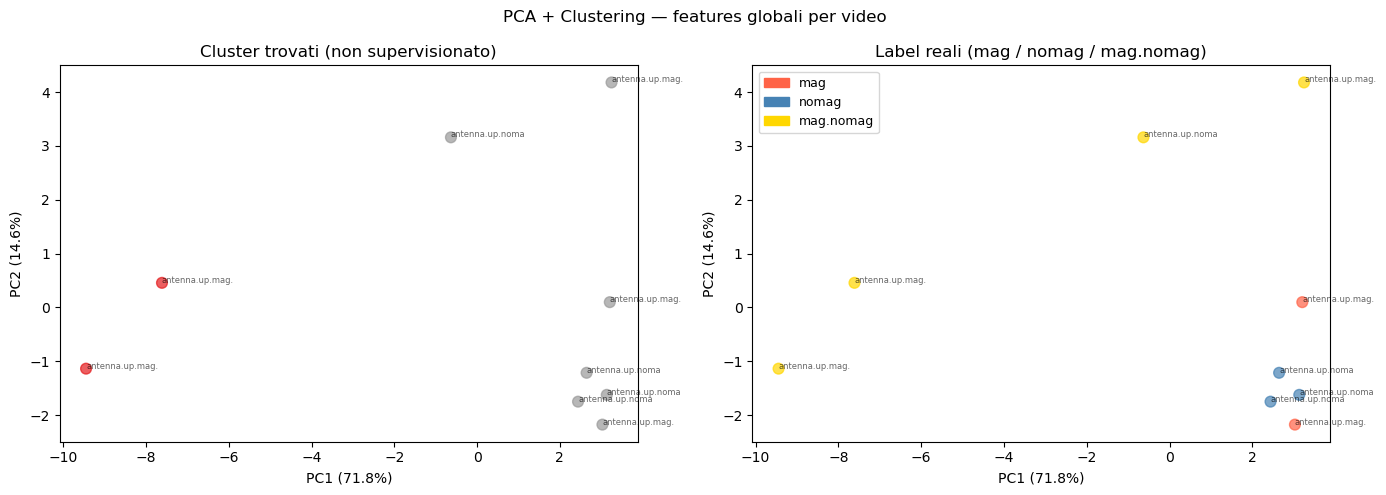


Confronto cluster vs label:
cluster    0  1
label          
mag        0  2
mag.nomag  2  2
nomag      0  3


In [21]:
# ============================================================
# CLUSTERING — on global features for videos
# ============================================================

features_df = pd.read_csv(FEATURES_OUTPUT)
feat_cols   = [c for c in features_df.columns
               if c not in ('video','label','duration_s',
                            'antenna_correlation_p')]

X_raw = features_df[feat_cols].values
# removes rows with NaN value
valid = ~np.isnan(X_raw).any(axis=1)
X_raw = X_raw[valid]
meta  = features_df[valid].reset_index(drop=True)

# standardize (necessary for clustering and PCA)
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X_raw)

# PCA for 2D visualization
pca   = PCA(n_components=2)
X_pca = pca.fit_transform(X_sc)

print(f"Variance explained by PC1+PC2: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# KMeans with 2 clusters (mag vs nomag)
# In case you have more conditions, change accordingly n_clusters
km     = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_km = km.fit_predict(X_sc)

# color plot for the flound clusters 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# pannel 1: cluster found by the model 
scatter = axes[0].scatter(X_pca[:,0], X_pca[:,1],
                          c=labels_km, cmap='Set1', alpha=0.7, s=60)
for i, row in meta.iterrows():
    axes[0].annotate(row['video'][:15], (X_pca[i,0], X_pca[i,1]),
                     fontsize=6, alpha=0.6)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].set_title("Cluster trovati (non supervisionato)")

# pannel 2: real labels (mag/nomag/mag.nomag)
label_colors = {'mag':'tomato','nomag':'steelblue',
                'mag.nomag':'gold', None:'gray'}
colors_real  = [label_colors.get(l, 'gray') for l in meta['label']]
axes[1].scatter(X_pca[:,0], X_pca[:,1], c=colors_real, alpha=0.7, s=60)
for i, row in meta.iterrows():
    axes[1].annotate(row['video'][:15], (X_pca[i,0], X_pca[i,1]),
                     fontsize=6, alpha=0.6)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("Label reali (mag / nomag / mag.nomag)")

# legenda manuale
from matplotlib.patches import Patch
legend = [Patch(color=v, label=k) for k,v in label_colors.items() if k]
axes[1].legend(handles=legend, fontsize=9)

plt.suptitle("PCA + Clustering — features globali per video")
plt.tight_layout()
plt.show()

# confronto cluster vs label
meta['cluster'] = labels_km
print("\nConfronto cluster vs label:")
print(pd.crosstab(meta['label'], meta['cluster']))

## How to interpret Clustering:
**A. Clusters found by the model (Left Graph - K-Means)**
This panel shows the result of unsupervised learning.

How the model thinks: The model (K-Means) is fed only the numerical metrics of the antennas (means, speed, asymmetries). The model knows absolutely nothing about which video contains the magnet experiment (mag) and which does not (nomag). It is "blind" to the biology or setup of the experiment.

What it does: It takes points in space and, based purely on mathematics and geometry (the distances between the data), attempts to divide them into two distinct groups based on the similarity of their movements. It creates Group 0 and Group 1.

Meaning: It represents how the data naturally clusters based on how the antennas move.

**B. Real Labels (Right Graph - Experimental Conditions)**
This panel shows the Experimental Reality (the real labels entered by you or the lab).

What it shows: Color the dots according to the actual condition the bee was in during the recording: mag (presence of a magnetic field), nomag (control), or mag.nomag (mixed or transitional condition).

Meaning: This is the biological/experimental truth.

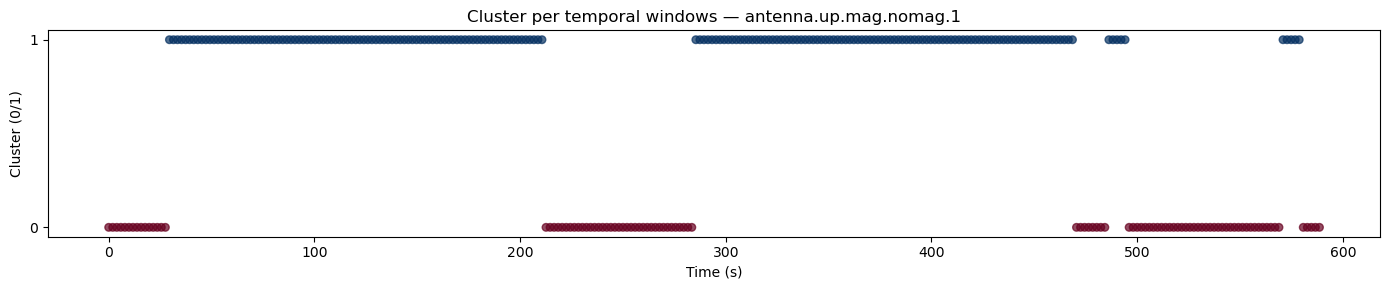

antenna.up.mag.nomag.1: cluster 0 = 103 windows, cluster 1 = 197 windows


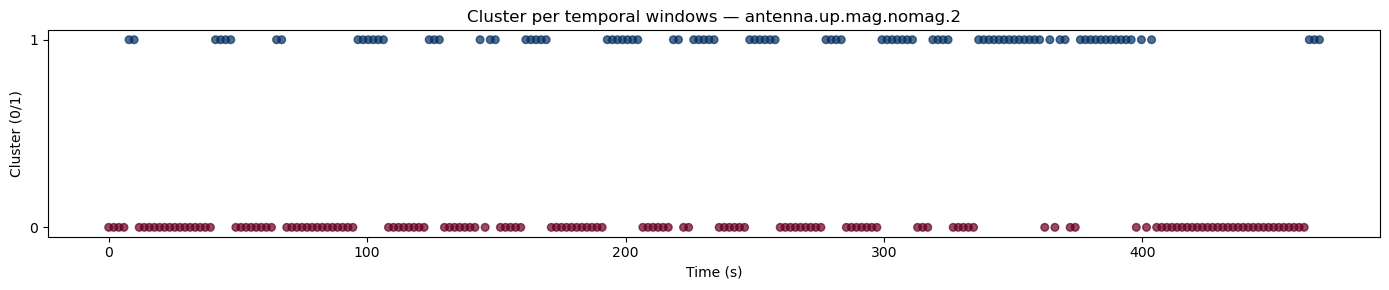

antenna.up.mag.nomag.2: cluster 0 = 147 windows, cluster 1 = 92 windows


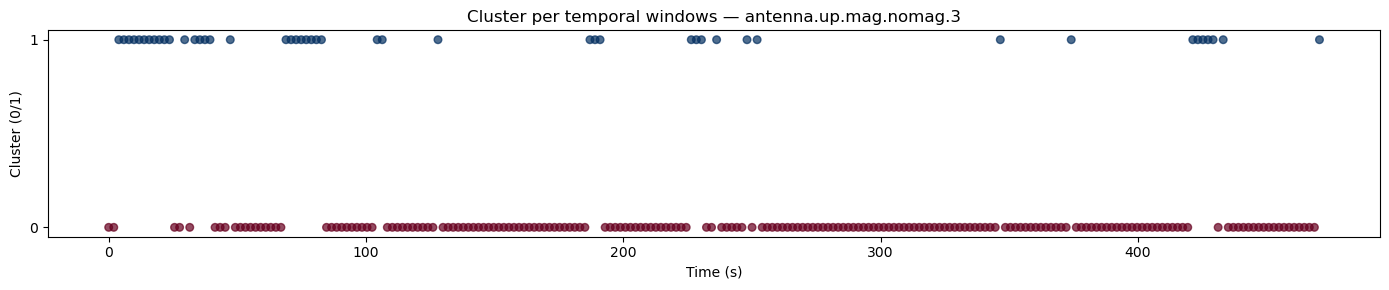

antenna.up.mag.nomag.3: cluster 0 = 194 windows, cluster 1 = 46 windows


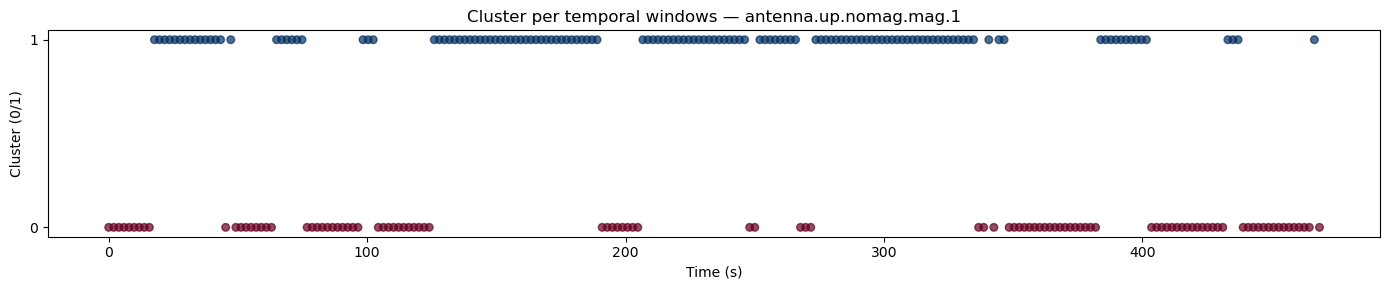

antenna.up.nomag.mag.1: cluster 0 = 104 windows, cluster 1 = 135 windows


In [22]:
# =================================================================
# CLUSTERING — on time windows (mag.nomag)
# ==============================================================================
# Analyzes mag.nomag videos window by window to check
# whether there are moments that behave like mag or nomag.

windows_df = pd.read_csv(FOLDER / "features_windows.csv")

feat_cols_w = [c for c in windows_df.columns
               if c not in ('video','label','window_start_s',
                            'window_end_s','antenna_correlation_p')]

# train clustering on mag + nomag
train_mask = windows_df['label'].isin(['mag','nomag'])
X_train_w  = windows_df.loc[train_mask, feat_cols_w].dropna()
valid_idx  = X_train_w.index

scaler_w = StandardScaler()
X_tr_sc  = scaler_w.fit_transform(X_train_w)

km_w = KMeans(n_clusters=2, random_state=42, n_init=10)
km_w.fit(X_tr_sc)

# apply to mag.nomag videos
mixed_mask = windows_df['label'] == 'mag.nomag'
mixed_vids = windows_df.loc[mixed_mask, 'video'].unique()

if len(mixed_vids) == 0:
    print("Nessun video mag.nomag trovato.")
else:
    for vid in mixed_vids:
        vid_mask = (windows_df['video'] == vid) & mixed_mask
        X_vid    = windows_df.loc[vid_mask, feat_cols_w].dropna()
        if len(X_vid) == 0:
            continue
        X_vid_sc = scaler_w.transform(X_vid)
        pred     = km_w.predict(X_vid_sc)
        t_start  = windows_df.loc[X_vid.index, 'window_start_s'].values

        fig, ax = plt.subplots(figsize=(14, 3))
        ax.scatter(t_start, pred, c=pred, cmap='RdBu', s=30, alpha=0.7)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Cluster (0/1)")
        ax.set_title(f"Cluster per temporal windows — {vid}")
        ax.set_yticks([0,1])
        plt.tight_layout()
        plt.show()
        print(f"{vid}: cluster 0 = {(pred==0).sum()} windows, "
              f"cluster 1 = {(pred==1).sum()} windows")

## 7. Supervised Classifier — mag vs nomag
Trained on mag and nomag, then applied to mag.nomag videos
to predict when the magnetic field is active.

Balanced accuracy (cross-val): 0.250 ± 0.250
(0.5 = casualty, 1.0 = perfect)


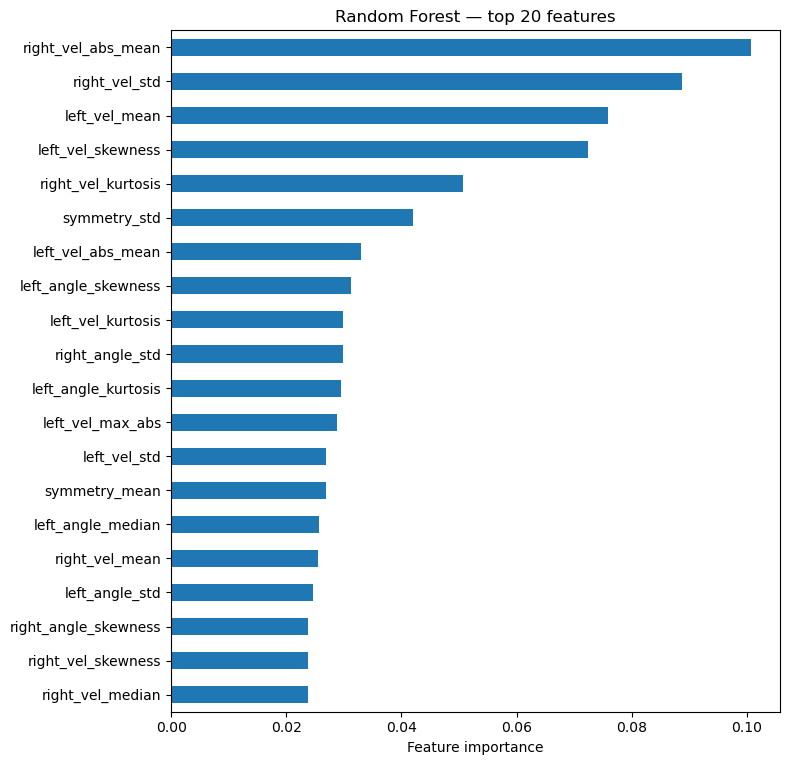

In [23]:
# ============================================================
# RANDOM FOREST — mag vs nomag (global features)
# ============================================================

features_df = pd.read_csv(FEATURES_OUTPUT)

# only use mag and nomag videos to train (no blackbox processes)
train_df = features_df[features_df['label'].isin(['mag','nomag'])].dropna(
    subset=feat_cols)

if len(train_df) < 4:
    print("Dati insufficienti per addestrare il classificatore.")
    print(f"There are {len(train_df)} videos labeled as mag/nomag — at least 4 videos are needed.")
else:
    X_clf = train_df[feat_cols].values
    y_clf = LabelEncoder().fit_transform(train_df['label'].values)

    clf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
    cv  = StratifiedKFold(n_splits=min(5, len(train_df)//2),
                          shuffle=True, random_state=42)
    scores = cross_val_score(clf, X_clf, y_clf, cv=cv,
                             scoring='balanced_accuracy')

    print(f"Balanced accuracy (cross-val): {scores.mean():.3f} ± {scores.std():.3f}")
    print("(0.5 = casualty, 1.0 = perfect)")

    # train on all mag/nomag data
    clf.fit(X_clf, y_clf)

    # feature importance
    importances = pd.Series(clf.feature_importances_,
                            index=feat_cols).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, max(6, len(feat_cols)*0.25)))
    importances.tail(20).plot.barh(ax=ax)
    ax.set_xlabel("Feature importance")
    ax.set_title("Random Forest — top 20 features")
    plt.tight_layout()
    plt.show()

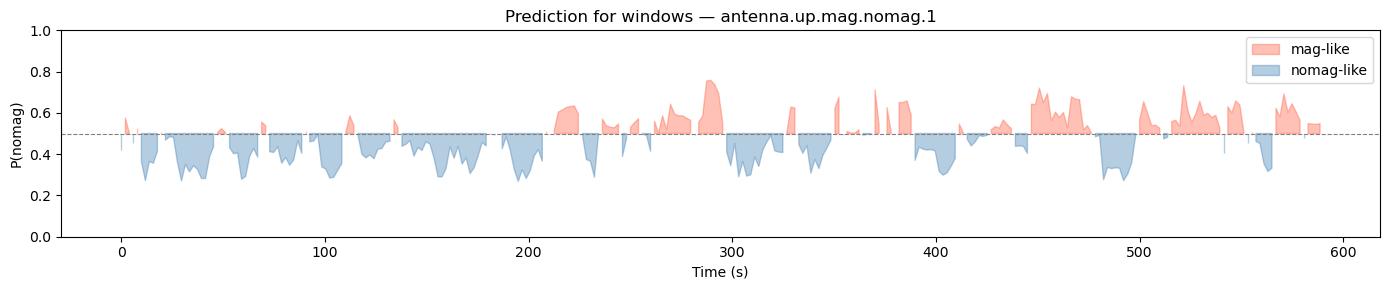

antenna.up.mag.nomag.1: 58.0% windows classified as MAG


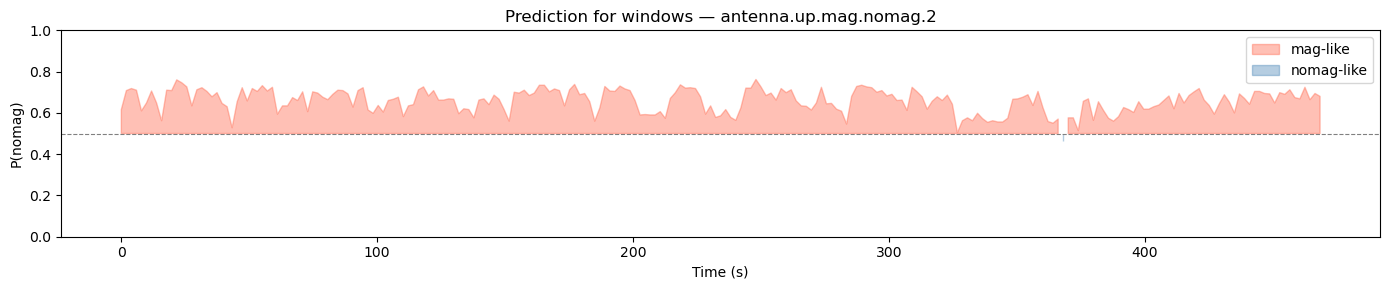

antenna.up.mag.nomag.2: 0.4% windows classified as MAG


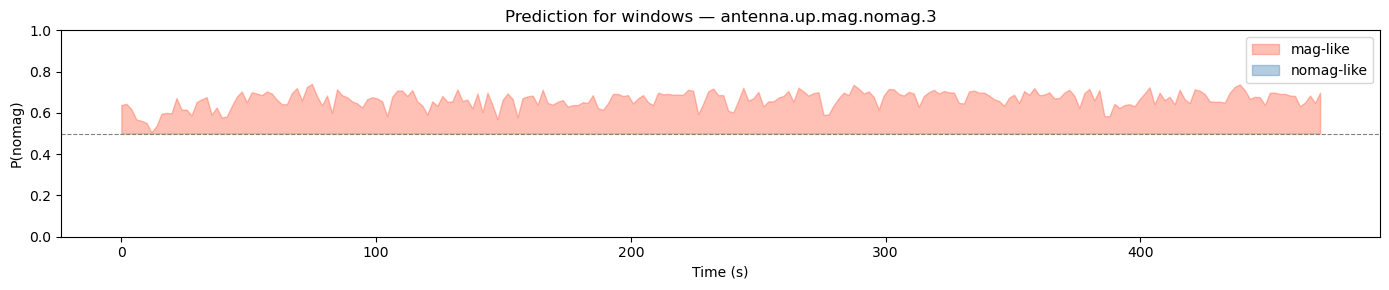

antenna.up.mag.nomag.3: 0.0% windows classified as MAG


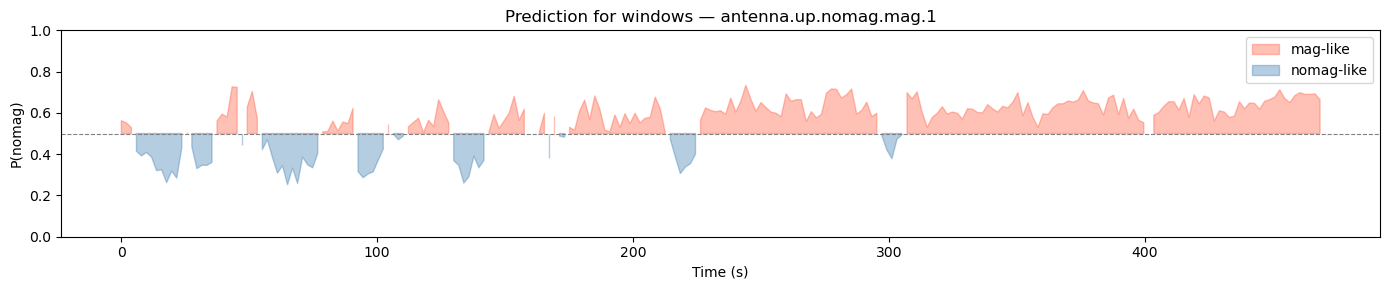

antenna.up.nomag.mag.1: 25.5% windows classified as MAG


In [24]:
# ==================================================================
# APPLICATION TO mag.nomag VIDEOS (artificial magnetic field fluctuation condition)
# ==================================================================================
# For each time window of the mixed videos, predict whether
# the behavior is more similar to mag or nomag.

windows_df = pd.read_csv(FOLDER / "features_windows.csv")
mixed_mask = windows_df['label'] == 'mag.nomag'
mixed_vids = windows_df.loc[mixed_mask, 'video'].unique()

feat_cols_w = [c for c in windows_df.columns
               if c not in ('video','label','window_start_s',
                            'window_end_s','antenna_correlation_p')]

if len(mixed_vids) == 0:
    print("No mag.nomag videos found.")
elif 'clf' not in dir():
    print("Run the classifier cell above first.")
else:
    le = LabelEncoder().fit(train_df['label'].values)

    for vid in mixed_vids:
        vid_mask = (windows_df['video'] == vid) & mixed_mask
        X_vid    = windows_df.loc[vid_mask, feat_cols_w].dropna()
        if len(X_vid) == 0:
            continue

        t_start = windows_df.loc[X_vid.index, 'window_start_s'].values
        proba   = clf.predict_proba(X_vid.values)[:,1]  # probability of being 'nomag'
        pred    = clf.predict(X_vid.values)
        labels_pred = le.inverse_transform(pred)

        fig, ax = plt.subplots(figsize=(14, 3))
        ax.fill_between(t_start, proba, 0.5, alpha=0.4,
                        where=proba > 0.5, color='tomato',   label='mag-like')
        ax.fill_between(t_start, proba, 0.5, alpha=0.4,
                        where=proba < 0.5, color='steelblue', label='nomag-like')
        ax.axhline(0.5, linestyle='--', color='gray', linewidth=0.8)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("P(nomag)")
        ax.set_title(f"Prediction for windows — {vid}")
        ax.set_ylim(0, 1)
        ax.legend()
        plt.tight_layout()
        plt.show()

        mag_frac = (labels_pred == 'mag').mean()
        print(f"{vid}: {mag_frac*100:.1f}% windows classified as MAG")